In [1]:
import pandas as pd
import numpy as np
from scratch.linear_algebra import Vector,dot
import math
from scratch.gradient_descent import gradient_step 
import random
import tqdm
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ==========================
# Import Data
# ==========================
df=pd.read_csv("Iot_result_smartfarming.csv")
print (f"columns\t:{df.shape[1]}\nRows\t:{df.shape[0]}")

columns	:7
Rows	:40


In [3]:
# Fungtion split data
def split_idx(idx:list[int],train_prob:float):
    random.shuffle(idx)
    cut =int(train_prob*len(idx))
    return idx[cut:],idx[:cut]

def split_train_test(xs:list[Vector],ys:Vector,test_prob:float):
    idx =[i for i in range(len(xs))]
    train_prob=1-test_prob
    idx_train,idx_test =split_idx(idx,train_prob)
    return (
        # train
        [xs[i] for i in idx_train],
        [ys[i] for i in idx_train],
        # test
        [xs[i] for i in idx_test],
        [ys[i] for i in idx_test]
    )



Build Model Neural Network

In [4]:
def step_fungtion(x:float):
    return 1.0 if x>=0 else 0.0

def preceptron_ouput(weights:Vector,bias:float,x:Vector):
    calculation=(dot(x,weights))+bias
    return step_fungtion(calculation)


In [5]:


# activation
def sigmoid(t):
    return 1 / (1 + math.exp(-t))

def neuron_output(weights, inputs):
    return sigmoid(dot(weights, inputs))

# feed forward
def feed_forward(network, inputs):
    outputs = []

    for layer in network:
        inputs_with_bias = inputs + [1]
        output = [
            neuron_output(neuron, inputs_with_bias)
            for neuron in layer
        ]
        outputs.append(output)
        inputs = output

    return outputs

In [6]:
def sqerror_gradient(networks:list[list[Vector]],inputs:Vector,targets:Vector):
    hidden_outputs,outputs =feed_forward(networks,inputs)
    output_deltas=[output*(1-output)*(output-target)for output,target in zip(outputs,targets)]
    output_gradient=[[output_deltas[i]*hidden_output for hidden_output in hidden_outputs+[1]]for i,output in enumerate(networks[-1])]
    hidden_deltas=[hidden_output*(1-hidden_output)*dot(output_deltas,[n[i] for n in networks[-1]])
                  for i,hidden_output  in enumerate(hidden_outputs)]
    hidden_gradient=[[hidden_deltas[i]*input for input in inputs+[1]] for i,hidden_neuron in enumerate(networks[0])]
    return [hidden_gradient,output_gradient]

In [7]:

def neural_network(xs:list[Vector],ys:Vector,epoch:int,neuron_:int,learning_rate=1.0):
    num_columns=len(xs[0])
    neurons=neuron_+1
    print (num_columns,neurons)
    hidden=[[random.random() for _ in range(num_columns+1)] for _ in range(neuron_)]
    output =[[random.random() for _ in range(neurons)]]
    network=[hidden,output]
    for t in tqdm.tgrange(epoch,desc='neural network'):
        for x,y  in zip (xs,ys) :
            gradients=sqerror_gradient(network,x,y)
            network=[[gradient_step(neuron,grad,-learning_rate) 
                      for neuron,grad in zip(layer,layer_grad)]
                      for layer,layer_grad in zip(network,gradients)]
    return network
    

In [13]:
columns_=df.columns[:-1]
for i in columns_:
    values=[]
    min=df[i].min()
    max =df[i].max()
    for j in range (len(df[df.columns[1]])):
        x = df.loc[j,i]
        value=(x-min)/(max-min)
        values.append(value)
    df[i]=values

In [14]:
df.head()

,soil_moisture,temperature,humidity,light_intensity,rain_probability,wind_speed,target
0,0.901961,0.272727,0.800000,0.227273,0.845238,0.666667,0
1,0.803922,0.454545,0.633333,0.000000,0.785714,0.500000,0
2,0.941176,0.181818,0.733333,0.318182,0.964286,0.833333,0
3,0.862745,0.363636,0.866667,0.181818,0.904762,0.666667,0
4,1.000000,0.090909,0.966667,0.272727,0.940476,1.000000,0


In [15]:
xs=df[df.columns[:-1]]
ys=df[df.columns[-1]]
xs= xs.values.tolist()
ys= [[y] for y in ys.values.tolist()]
xs_train,ys_train,xs_test,ys_test=split_train_test(xs,ys,0.10)


Train Models

6 6


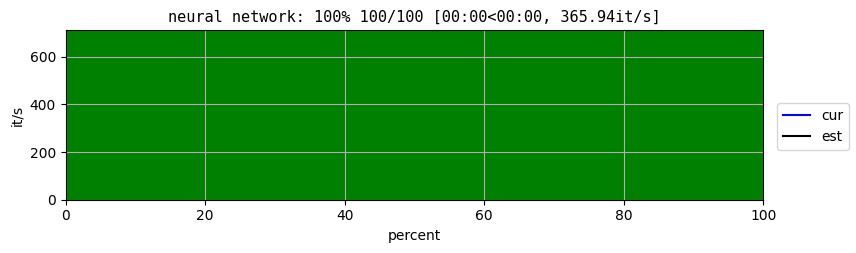

In [36]:
# data 1
network =neural_network(xs_train,ys_train,100,5)

In [24]:
def fungsi_(y_true, y_pred):
    tp = sum(1 for yt, yp in zip(y_true, y_pred) if yt==1 and yp==1)
    tn = sum(1 for yt, yp in zip(y_true, y_pred) if yt==0 and yp==0)
    fp = sum(1 for yt, yp in zip(y_true, y_pred) if yt==0 and yp==1)
    fn = sum(1 for yt, yp in zip(y_true, y_pred) if yt==1 and yp==0)

    total = tp + tn + fp + fn

    accuracy  = (tp + tn) / total if total else 0
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall    = tp / (tp + fn) if (tp + fn) else 0
    f1_score  = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0

    return accuracy, precision, recall, f1_score

In [21]:
def evaluasi_nn(ys_test, xs_test, network):
    y_predicts = []

    for x in xs_test:
        y_pred = feed_forward(network, x)[1][0]
        y_predicts.append(1 if y_pred > 0.5 else 0)

    # Flatten ys_test kalau bentuknya [[1],[0]]
    if isinstance(ys_test[0], list):
        y_test = [y[0] for y in ys_test]
    else:
        y_test = ys_test

    accuracy, precision, recall, f1_score = fungsi_(y_test, y_predicts)

    print(f"Accuracy : {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall   : {recall}")
    print(f"F1 Score : {f1_score}")

In [37]:
evaluasi_nn(ys_test,xs_test,network)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
